## Event Study: Haben die Tweets von Trump einen signifikanten Effekt auf die WTI Kurse?

In [30]:
import numpy as np
import pandas as pd

from scipy.stats import (
    ttest_1samp,
    wilcoxon,
    mannwhitneyu
)

import matplotlib.pyplot as plt

In [31]:
# --------------------------------------------------
# Event Study Parameter
# --------------------------------------------------

PRE_EVENT_WINDOW = 30      # Minuten vor Tweet
POST_EVENT_WINDOW = 60     # Minuten nach Tweet

# Schätzung der "normalen" Rendite
ESTIMATION_WINDOW = 120    # Minuten vor Event

# zu untersuchende Horizonte
EVENT_HORIZONS = [5, 15, 30, 60]

# Anzahl Placebo-Events
N_RANDOM_EVENTS = 1000

RANDOM_SEED = 42

In [32]:
# --------------------------------------------------
# Tweets
# --------------------------------------------------

tweets = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\tweets_v2.csv",
    parse_dates=["timestamp_utc"]
)

# --------------------------------------------------
# WTI OHLC
# --------------------------------------------------

wti = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\wti_v2.csv",
    parse_dates=["timestamp_utc"]
)

wti = wti.sort_values("timestamp_utc")
wti = wti.set_index("timestamp_utc")

In [33]:
# --------------------------------------------------
# Log Returns
# --------------------------------------------------

wti["return"] = np.log(
    wti["close"] / wti["close"].shift(1)
)

wti = wti.dropna()

In [34]:
def map_to_market_timestamp(event_time, market_index):
    """
    Mappt einen Tweet auf die erste verfügbare Marktminute.
    """

    pos = market_index.searchsorted(event_time)

    if pos >= len(market_index):
        return None

    return market_index[pos]

In [35]:
def extract_event_data(
    market_df,
    event_time,
    estimation_window=120,
    pre_window=30,
    post_window=60
):
    """
    Extrahiert die Daten eines einzelnen Events.

    Returns:
        estimation_returns
        event_returns
    """

    idx = market_df.index

    event_timestamp = map_to_market_timestamp(
        event_time,
        idx
    )

    if event_timestamp is None:
        return None

    center_loc = idx.get_loc(event_timestamp)

    estimation_start = (
        center_loc
        - estimation_window
        - pre_window
    )

    estimation_end = (
        center_loc
        - pre_window
        - 1
    )

    event_start = center_loc - pre_window
    event_end = center_loc + post_window

    # Vollständige Fenster erzwingen
    if (
        estimation_start < 0
        or event_end >= len(idx)
    ):
        return None

    estimation_returns = (
        market_df.iloc[
            estimation_start:
            estimation_end + 1
        ]["return"]
        .values
    )

    event_returns = (
        market_df.iloc[
            event_start:
            event_end + 1
        ]["return"]
        .values
    )

    return (
        estimation_returns,
        event_returns
    )

In [36]:
event_records = []

for _, tweet in tweets.iterrows():

    result = extract_event_data(
        market_df=wti,
        event_time=tweet["timestamp_utc"],
        estimation_window=ESTIMATION_WINDOW,
        pre_window=PRE_EVENT_WINDOW,
        post_window=POST_EVENT_WINDOW
    )

    if result is None:
        continue

    estimation_returns, event_returns = result

    event_records.append(
        {
            "tweet_id": tweet["id"],
            "timestamp": tweet["timestamp_utc"],
            "estimation_returns": estimation_returns,
            "event_returns": event_returns
        }
    )

print(f"Valid Events: {len(event_records)}")

Valid Events: 46496


In [37]:
abnormal_return_matrix = []

for event in event_records:

    expected_return = np.mean(
        event["estimation_returns"]
    )

    abnormal_returns = (
        event["event_returns"]
        - expected_return
    )

    abnormal_return_matrix.append(
        abnormal_returns
    )

abnormal_return_matrix = np.array(
    abnormal_return_matrix
)

In [38]:
relative_minutes = np.arange(
    -PRE_EVENT_WINDOW,
    POST_EVENT_WINDOW + 1
)

abnormal_df = pd.DataFrame(
    abnormal_return_matrix,
    columns=relative_minutes
)

abnormal_df.head()

,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,...,51,52,53,54,55,56,57,58,59,60
0,0.000898,0.000471,0.000045,0.000791,-0.001340,0.000152,0.000685,0.000045,0.000152,0.000471,...,-0.000274,0.000578,-0.000274,-0.000168,-0.000807,0.000365,0.000578,-0.000274,-0.000061,0.000365
1,-0.000829,-0.000830,-0.000417,-0.000520,0.000204,-0.000003,-0.000727,-0.000313,-0.000624,-0.000210,...,-0.000106,0.000936,-0.000523,-0.000315,0.001144,-0.000627,-0.000836,0.000727,0.000102,-0.000106
2,-0.000145,-0.000680,-0.001082,-0.000279,-0.000011,-0.000011,-0.000681,0.000391,0.000391,-0.000279,...,0.000257,0.000658,0.000123,-0.000279,-0.000279,0.000257,-0.000413,-0.001753,-0.000011,-0.000011
3,-0.000212,-0.000212,-0.000018,-0.000018,-0.000212,-0.000212,-0.000018,-0.000018,0.000176,-0.000406,...,0.000571,-0.000018,0.000198,-0.000234,-0.000214,0.000374,0.000570,0.000178,-0.000214,-0.000606
4,0.000002,0.000002,-0.000244,-0.000244,0.000002,0.000002,-0.000244,0.000002,0.000002,-0.000244,...,-0.000493,0.000497,0.000002,-0.000245,0.000250,-0.000369,0.000126,-0.000989,-0.000494,0.000002


In [39]:
aar = abnormal_df.mean(axis=0)

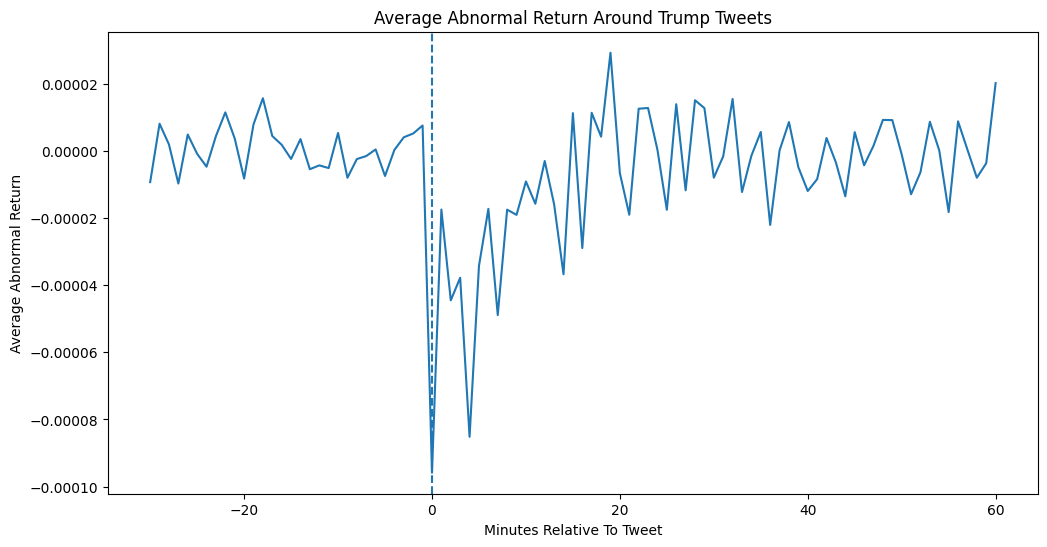

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    aar.index,
    aar.values
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Average Abnormal Return Around Trump Tweets"
)

plt.xlabel(
    "Minutes Relative To Tweet"
)

plt.ylabel(
    "Average Abnormal Return"
)

plt.show()

In [41]:
caar = aar.cumsum()

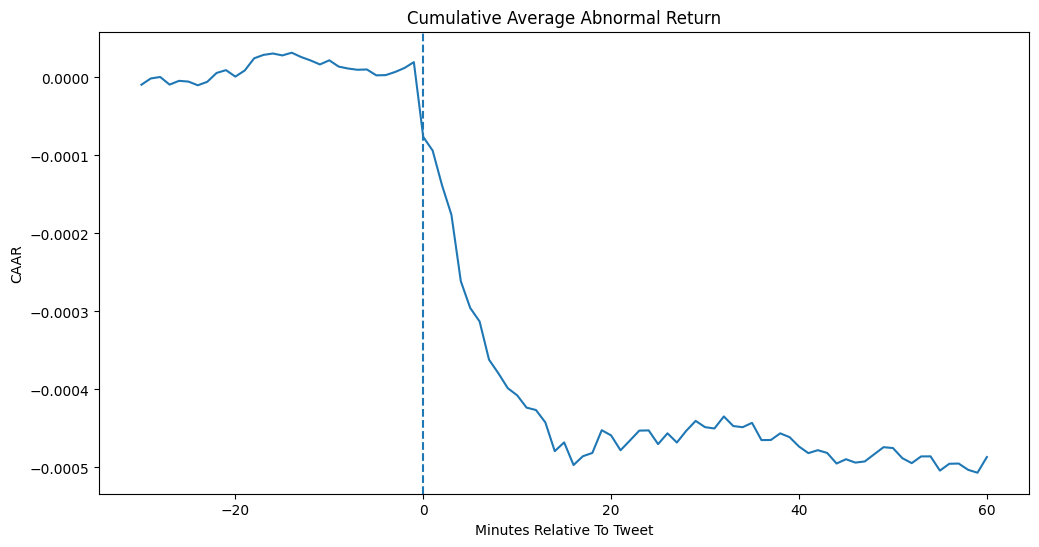

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    caar.index,
    caar.values
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Cumulative Average Abnormal Return"
)

plt.xlabel(
    "Minutes Relative To Tweet"
)

plt.ylabel(
    "CAAR"
)

plt.show()

In [43]:
car_results = {}

for horizon in EVENT_HORIZONS:

    car = (
        abnormal_df
        .loc[:, 1:horizon]
        .sum(axis=1)
    )

    car_results[horizon] = car

In [44]:
for horizon, car in car_results.items():

    t_stat, p_value = ttest_1samp(
        car,
        0
    )

    print("\n")
    print(f"Horizon: {horizon} min")
    print(f"T-stat: {t_stat:.4f}")
    print(f"P-value: {p_value:.100f}")



Horizon: 5 min
T-stat: -13.7952
P-value: 0.0000000000000000000000000000000000000000003315692563064482571600311889193202040060385617074949033427


Horizon: 15 min
T-stat: -18.1568
P-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000002035750400472945547981025681


Horizon: 30 min
T-stat: -13.7528
P-value: 0.0000000000000000000000000000000000000000005945823743677353244803171574573251831556799998685498300919


Horizon: 60 min
T-stat: -10.2405
P-value: 0.0000000000000000000000013866836599329738509328408224046177243555237325982397103401269367614970229319


In [45]:
for horizon, car in car_results.items():

    stat, p_value = wilcoxon(car)

    print("\n")
    print(f"Horizon: {horizon} min")
    print(f"Wilcoxon p-value: {p_value:.6f}")



Horizon: 5 min
Wilcoxon p-value: 0.000000


Horizon: 15 min
Wilcoxon p-value: 0.000000


Horizon: 30 min
Wilcoxon p-value: 0.000000


Horizon: 60 min
Wilcoxon p-value: 0.000000


In [46]:
rng = np.random.default_rng(
    RANDOM_SEED
)

In [47]:
valid_start = (
    ESTIMATION_WINDOW
    + PRE_EVENT_WINDOW
)

valid_end = (
    len(wti)
    - POST_EVENT_WINDOW
    - 1
)

In [48]:
random_positions = rng.choice(
    np.arange(valid_start, valid_end),
    size=N_RANDOM_EVENTS,
    replace=False
)

In [49]:
placebo_cars = []

for pos in random_positions:

    estimation_returns = (
        wti.iloc[
            pos - ESTIMATION_WINDOW - PRE_EVENT_WINDOW:
            pos - PRE_EVENT_WINDOW
        ]["return"]
        .values
    )

    expected_return = np.mean(
        estimation_returns
    )

    event_returns = (
        wti.iloc[
            pos:
            pos + 15
        ]["return"]
        .values
    )

    abnormal_returns = (
        event_returns
        - expected_return
    )

    placebo_cars.append(
        abnormal_returns.sum()
    )

placebo_cars = np.array(
    placebo_cars
)

In [50]:
tweet_car_15 = (
    abnormal_df.loc[:, 1:15]
    .sum(axis=1)
)

In [51]:
u_stat, p_value = mannwhitneyu(
    tweet_car_15,
    placebo_cars,
    alternative="two-sided"
)

print("\nPlacebo Test")
print("------------")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.6f}")


Placebo Test
------------
U-statistic: 21914186.5000
P-value: 0.001876


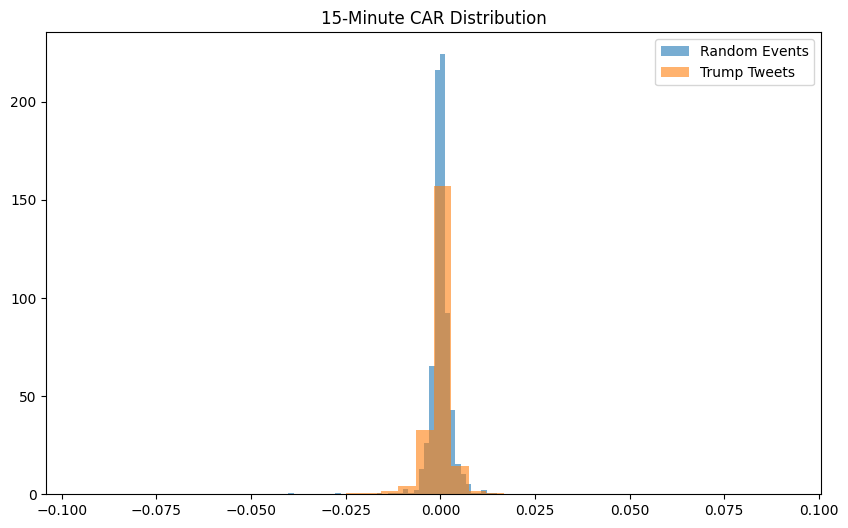

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(
    placebo_cars,
    bins=40,
    alpha=0.6,
    density=True,
    label="Random Events"
)

plt.hist(
    tweet_car_15,
    bins=40,
    alpha=0.6,
    density=True,
    label="Trump Tweets"
)

plt.legend()

plt.title(
    "15-Minute CAR Distribution"
)

plt.show()